# Noisy NNLS Row-Action Experiment

This notebook implements the numerical experiment for Section 6.1, `Noisy nonnegative least squares`.

The goal is to test the row-action algorithm proposed in the paper on an inconsistent/noisy NNLS problem and to check the step-size behavior predicted by the theory:

- constant step sizes should converge quickly but settle in a noise-dependent neighborhood;
- smaller constant step sizes should produce smaller final neighborhoods;
- horizon-tuned step sizes of the form $\eta_0/\sqrt{T}$ are compared against constant and diminishing step-size rules.

## Table of Contents

- [1. Setup and utilities](#1-setup-and-utilities)
- [2. Synthetic noisy NNLS data](#2-synthetic-noisy-nnls-data)
- [3. Single-run step-size comparison](#3-single-run-step-size-comparison)
- [4. Constant step-size noise floor](#4-constant-step-size-noise-floor)
- [5. Horizon-tuned rate check](#5-horizon-tuned-rate-check)
- [6. Paper-style figure export](#6-paper-style-figure-export)

## Run Guide

| Section | Purpose | Main outputs |
|---|---|---|
| 1 | Define the row-action NNLS solver, reference NNLS solver, schedules, and plotting helpers. | functions |
| 2 | Build a noisy inconsistent NNLS instance and compute a reference optimum. | `A`, `b`, `x_star`, `f_star` |
| 3 | Compare representative step-size rules in one run. | `single_results` |
| 4 | Estimate the noise floor for several constant step sizes. | `floor_rows` |
| 5 | Check the $\eta_0/\sqrt{T}$ horizon rule across several horizons. | `rate_rows`, `rate_slope` |
| 6 | Save the main figures as PDF files. | files in `figures_nnls_noisy/` |


**Compliance update.** This version preserves every experiment, diagnostic, printed summary, displayed figure, and PDF export from Zeyu's original notebook. The weighted average now uses the pre-update iterates \(x_k\), as in Theorem 5.9, and the diminishing-step labels use the paper indexing \(\eta_k=\eta_0/\sqrt{k+1}\). The original figure filenames are retained; one additional alias is exported for the filename used by the current paper source.

The saved cell outputs are retained only as a visual record of the original notebook. After copying this file into the project, use **Restart Kernel and Run All** to regenerate all numerical values and figures with the corrected code.

## 1. Setup and utilities

The algorithm below is the projected randomized row-action method for

$$
\begin{aligned}
&\underset{x}{\operatorname{minimize}} && \frac{1}{2}\lVert Ax-b\rVert_2^2 \\
&\operatorname{subject\ to} && x\ge 0.
\end{aligned}
$$

At iteration $k$, it samples row $i$ with probability proportional to $\lVert a_i\rVert_2^2$ and applies

$$
x_{k+1}=P_+\!\left(x_k-\eta_k\frac{a_i^{\top}x_k-b_i}{\lVert a_i\rVert_2^2}a_i\right).
$$

For the displayed noisy experiment, the theory-aligned quantity is the weighted-average objective gap $f(\bar{x}_k)-f^\star$, with the average formed from the pre-update iterates $x_k$, exactly as in Theorem 5.9. The last-iterate gap is still computed as a practical reference.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

try:
    from scipy.optimize import nnls as scipy_nnls
    HAVE_SCIPY_NNLS = True
except Exception:
    scipy_nnls = None
    HAVE_SCIPY_NNLS = False

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


# ============================================================
# Basic NNLS utilities
# ============================================================

def project_nonnegative(x):
    return np.maximum(x, 0.0)


def nnls_objective(A, b, x):
    r = A @ x - b
    return 0.5 * float(np.dot(r, r))


def relative_residual(A, b, x):
    denom = max(np.linalg.norm(b), 1e-15)
    return np.linalg.norm(A @ x - b) / denom


def support_size(x, tol=1e-10):
    return int(np.sum(x > tol))


def safe_gap(value, floor=1e-16):
    return np.maximum(value, floor)


# ============================================================
# Synthetic noisy NNLS data
# ============================================================

def make_noisy_nnls_data(
    m=300,
    n=80,
    sparsity=0.25,
    noise_level=0.05,
    seed=0,
    normalize_rows=False,
):
    """
    Generate b = A x_true + noise with x_true >= 0.

    The noise is scaled so that ||noise|| / ||A x_true|| = noise_level.
    For noise_level > 0, the exact system Ax=b is generically inconsistent.
    """
    rng = np.random.default_rng(seed)

    A = rng.standard_normal((m, n)) / np.sqrt(n)
    if normalize_rows:
        row_norms = np.linalg.norm(A, axis=1, keepdims=True)
        A = A / np.maximum(row_norms, 1e-15)

    s = max(1, int(round(sparsity * n)))
    support = rng.choice(n, size=s, replace=False)
    x_true = np.zeros(n)
    x_true[support] = rng.uniform(0.5, 2.0, size=s)

    clean = A @ x_true
    raw_noise = rng.standard_normal(m)
    raw_norm = max(np.linalg.norm(raw_noise), 1e-15)
    clean_norm = max(np.linalg.norm(clean), 1e-15)
    noise = noise_level * clean_norm * raw_noise / raw_norm
    b = clean + noise

    return A, b, x_true, clean, noise


# ============================================================
# Reference NNLS solver
# ============================================================

def nnls_fista_reference(A, b, max_iter=30000, tol=1e-11):
    """
    Fallback deterministic projected-gradient/FISTA NNLS solver.

    scipy.optimize.nnls is used when available. This fallback keeps the
    notebook self-contained if SciPy's NNLS routine is unavailable.
    """
    _, n = A.shape
    L = np.linalg.norm(A, ord=2) ** 2
    if L <= 0:
        return np.zeros(n), {"method": "fista", "n_iter": 0, "objective": np.array([])}

    x = np.zeros(n)
    y = x.copy()
    t = 1.0
    obj_hist = []

    for it in range(max_iter):
        grad = A.T @ (A @ y - b)
        x_next = project_nonnegative(y - grad / L)
        obj_next = nnls_objective(A, b, x_next)

        if obj_hist and obj_next > obj_hist[-1] + 1e-14:
            y = x.copy()
            t = 1.0
            grad = A.T @ (A @ y - b)
            x_next = project_nonnegative(y - grad / L)
            obj_next = nnls_objective(A, b, x_next)

        obj_hist.append(obj_next)
        step_norm = np.linalg.norm(x_next - x)
        if step_norm <= tol * max(1.0, np.linalg.norm(x)):
            x = x_next
            break

        t_next = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        y = x_next + ((t - 1.0) / t_next) * (x_next - x)
        x = x_next
        t = t_next

    return x, {"method": "fista", "n_iter": len(obj_hist), "objective": np.array(obj_hist)}


def solve_nnls_reference(A, b, max_iter=30000, tol=1e-11):
    """
    Compute a high-accuracy NNLS reference solution.
    """
    if HAVE_SCIPY_NNLS:
        x_star, rnorm = scipy_nnls(A, b, maxiter=max_iter)
        return x_star, {
            "method": "scipy.optimize.nnls",
            "rnorm": float(rnorm),
            "objective": np.array([0.5 * rnorm * rnorm]),
        }

    return nnls_fista_reference(A, b, max_iter=max_iter, tol=tol)


# ============================================================
# Step-size schedules
# ============================================================

def make_schedule(kind, eta0):
    return {"kind": kind, "eta0": float(eta0)}


def eta_from_schedule(schedule, k, total_iters):
    """
    Return the stepsize for one-based loop index k. Thus the diminishing rule eta0/sqrt(k) implements eta_j=eta0/sqrt(j+1) in the zero-based paper notation.
    """
    if callable(schedule):
        return float(schedule(k, total_iters))

    kind = schedule["kind"]
    eta0 = float(schedule["eta0"])

    if kind == "constant":
        return eta0
    if kind == "horizon_sqrt":
        return eta0 / np.sqrt(total_iters)
    if kind == "diminishing_sqrt":
        return eta0 / np.sqrt(k)

    raise ValueError(f"Unknown schedule kind: {kind}")


# ============================================================
# Randomized projected row-action NNLS solver
# ============================================================

def projected_row_action_nnls(
    A,
    b,
    n_iters,
    eta_schedule,
    seed=0,
    x0=None,
    x_star=None,
    f_star=None,
    record_every=None,
):
    """
    Projected randomized row-action method for noisy NNLS.

    Records the last iterate and the weighted average iterate
        xbar_K = sum_k eta_k x_k / sum_k eta_k,
    matching the averaged quantities used in the noisy-regime theory.
    """
    rng = np.random.default_rng(seed)
    m, n = A.shape

    row_norm_sq = np.sum(A * A, axis=1)
    if np.any(row_norm_sq <= 0):
        raise ValueError("All rows of A must have positive norm.")
    probs = row_norm_sq / np.sum(row_norm_sq)

    if x0 is None:
        x = np.zeros(n)
    else:
        x = project_nonnegative(np.array(x0, dtype=float, copy=True))

    if record_every is None:
        record_every = m

    avg_sum = np.zeros(n)
    eta_sum = 0.0
    t0 = perf_counter()

    hist = {
        "iter": [],
        "epoch": [],
        "time": [],
        "eta": [],
        "objective": [],
        "objective_gap": [],
        "relative_residual": [],
        "distance_to_star": [],
        "avg_objective": [],
        "avg_objective_gap": [],
        "avg_distance_to_star": [],
    }

    def record(k, eta_used):
        x_avg = x if eta_sum == 0.0 else avg_sum / eta_sum
        obj = nnls_objective(A, b, x)
        avg_obj = nnls_objective(A, b, x_avg)

        hist["iter"].append(k)
        hist["epoch"].append(k / m)
        hist["time"].append(perf_counter() - t0)
        hist["eta"].append(eta_used)
        hist["objective"].append(obj)
        hist["relative_residual"].append(relative_residual(A, b, x))
        hist["avg_objective"].append(avg_obj)

        if f_star is None:
            hist["objective_gap"].append(np.nan)
            hist["avg_objective_gap"].append(np.nan)
        else:
            hist["objective_gap"].append(max(obj - f_star, 0.0))
            hist["avg_objective_gap"].append(max(avg_obj - f_star, 0.0))

        if x_star is None:
            hist["distance_to_star"].append(np.nan)
            hist["avg_distance_to_star"].append(np.nan)
        else:
            hist["distance_to_star"].append(np.linalg.norm(x - x_star))
            hist["avg_distance_to_star"].append(np.linalg.norm(x_avg - x_star))

    record(0, 0.0)
    eta_used = 0.0

    for k in range(1, n_iters + 1):
        eta = eta_from_schedule(eta_schedule, k, n_iters)
        i = rng.choice(m, p=probs)

        # Theory-aligned weighted average:
        # add the pre-update iterate x_k before computing x_{k+1}.
        avg_sum += eta * x
        eta_sum += eta

        ai = A[i, :]
        residual_i = float(ai @ x - b[i])
        correction = (residual_i / row_norm_sq[i]) * ai
        x = project_nonnegative(x - eta * correction)

        eta_used = eta

        if k % record_every == 0 or k == n_iters:
            record(k, eta_used)

    for key in hist:
        hist[key] = np.array(hist[key])

    x_avg = x if eta_sum == 0.0 else avg_sum / eta_sum
    return x, x_avg, hist


# ============================================================
# Experiment helpers
# ============================================================

def print_reference_summary(A, b, x_true, clean, noise, x_star, f_star, ref_info):
    print("Reference solver:", ref_info["method"])
    print("A shape:", A.shape)
    print("Relative noise ||e||/||Ax_true||:", np.linalg.norm(noise) / max(np.linalg.norm(clean), 1e-15))
    print("True support size:", support_size(x_true))
    print("NNLS support size:", support_size(x_star))
    print("f_star = 0.5 ||A x_star - b||^2:", f_star)
    print("relative residual at x_star:", relative_residual(A, b, x_star))
    print("relative residual at x_true:", relative_residual(A, b, x_true))


def run_many_final_avg_gaps(A, b, n_iters, eta_schedule, f_star, x_star=None, n_repeats=8, seed0=100):
    gaps = []
    last_gaps = []
    distances = []

    for rep in range(n_repeats):
        _, _, hist = projected_row_action_nnls(
            A,
            b,
            n_iters=n_iters,
            eta_schedule=eta_schedule,
            seed=seed0 + rep,
            x_star=x_star,
            f_star=f_star,
            record_every=n_iters,
        )
        gaps.append(hist["avg_objective_gap"][-1])
        last_gaps.append(hist["objective_gap"][-1])
        distances.append(hist["avg_distance_to_star"][-1])

    return np.array(gaps), np.array(last_gaps), np.array(distances)


def summarize_samples(values):
    return {
        "median": float(np.median(values)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
    }


def print_rows(rows, columns):
    widths = [max(len(c), 12) for c in columns]
    header = " ".join(c.rjust(w) for c, w in zip(columns, widths))
    print(header)
    print("-" * len(header))
    for row in rows:
        parts = []
        for c, w in zip(columns, widths):
            value = row[c]
            if isinstance(value, str):
                parts.append(value.rjust(w))
            elif isinstance(value, int):
                parts.append(f"{value:d}".rjust(w))
            else:
                parts.append(f"{value:.4e}".rjust(w))
        print(" ".join(parts))


## 2. Synthetic noisy NNLS data

This cell creates the noisy inconsistent NNLS instance and computes a high-accuracy NNLS reference solution `x_star`. The stochastic row-action method is then evaluated by the objective gap

$$
\frac{1}{2}\lVert Ax-b\rVert_2^2-\frac{1}{2}\lVert Ax^\star-b\rVert_2^2.
$$


In [2]:
# ============================================================
# Generate one noisy NNLS instance
# ============================================================

DATA_CONFIG = {
    "m": 1000,
    "n": 200,
    "sparsity": 0.25,
    "noise_level": 0.05,
    "seed": 8,
    "normalize_rows": False,
}

A, b, x_true, clean, noise = make_noisy_nnls_data(**DATA_CONFIG)

x_star, ref_info = solve_nnls_reference(A, b)
f_star = nnls_objective(A, b, x_star)

print_reference_summary(A, b, x_true, clean, noise, x_star, f_star, ref_info)


Reference solver: scipy.optimize.nnls
A shape: (1000, 200)
Relative noise ||e||/||Ax_true||: 0.05000000000000001
True support size: 50
NNLS support size: 122
f_star = 0.5 ||A x_star - b||^2: 0.4099496340562918
relative residual at x_star: 0.046948599732974106
relative residual at x_true: 0.049947965644168146


## 3. Single-run step-size comparison

This section compares several representative step-size choices on the same noisy NNLS instance.

The `horizon_sqrt` rule uses a constant value within the run, $\eta_k=\eta_0/\sqrt{T}$, where $T$ is the total number of row updates in that run. This is the horizon-tuned choice suggested by the noisy-regime bound.


In [3]:
# ============================================================
# Compare representative schedules in one run
# ============================================================

n_epochs_single = 2000
n_iters_single = n_epochs_single * A.shape[0]
record_every = A.shape[0]

schedules = {
    r"$\eta_k=0.9$": make_schedule("constant", 0.9),
    r"$\eta_k=0.2$": make_schedule("constant", 0.2),
    r"$\eta_k=\eta_0/\sqrt{T},\ \eta_0=0.9$": make_schedule("horizon_sqrt", 0.9),
    r"$\eta_k=\eta_0/\sqrt{k+1},\ \eta_0=0.9$": make_schedule("diminishing_sqrt", 0.9),
}

single_results = {}

for name, schedule in schedules.items():
    print(f"\nRunning {name}")
    x_last, x_avg, hist = projected_row_action_nnls(
        A,
        b,
        n_iters=n_iters_single,
        eta_schedule=schedule,
        seed=20,
        x_star=x_star,
        f_star=f_star,
        record_every=record_every,
    )
    single_results[name] = {
        "x_last": x_last,
        "x_avg": x_avg,
        "hist": hist,
        "schedule": schedule,
    }
    print("final last objective gap:", hist["objective_gap"][-1])
    print("final weighted-average objective gap:", hist["avg_objective_gap"][-1])
    print("final relative residual:", hist["relative_residual"][-1])
    print("final eta:", hist["eta"][-1])



Running $\eta_k=0.9$
final last objective gap: 0.32985945713579845
final weighted-average objective gap: 0.13616491840798406
final relative residual: 0.06306918575363979
final eta: 0.9

Running $\eta_k=0.2$
final last objective gap: 0.0596351655259702
final weighted-average objective gap: 0.023112838481041287
final relative residual: 0.0502474940445737
final eta: 0.2

Running $\eta_k=\eta_0/\sqrt{T},\ \eta_0=0.9$
final last objective gap: 0.03573872947589113
final weighted-average objective gap: 6.010608736104443
final relative residual: 0.04895229302115326
final eta: 0.0006363961030678928

Running $\eta_k=\eta_0/\sqrt{k+1},\ \eta_0=0.9$
final last objective gap: 0.000251932785310105
final weighted-average objective gap: 1.6099994935072421
final relative residual: 0.04696302354736236
final eta: 0.0006363961030678928


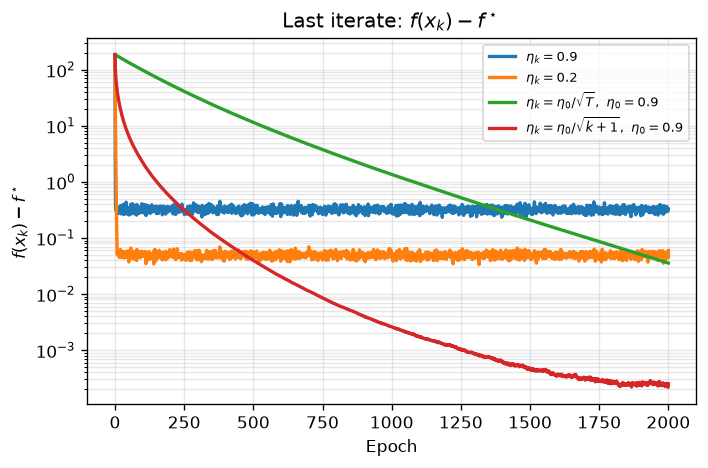

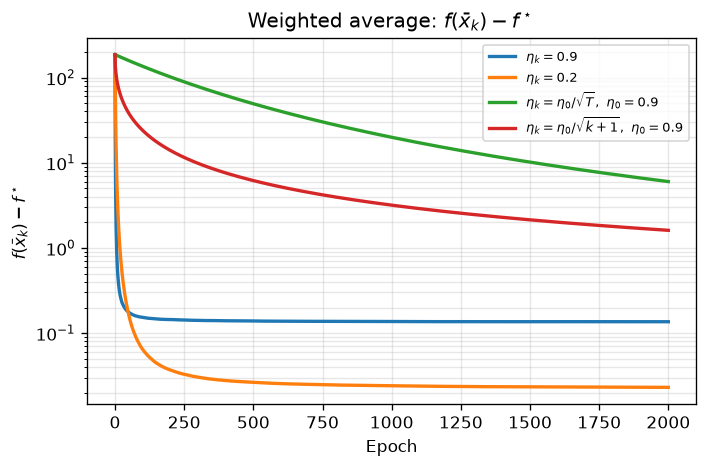

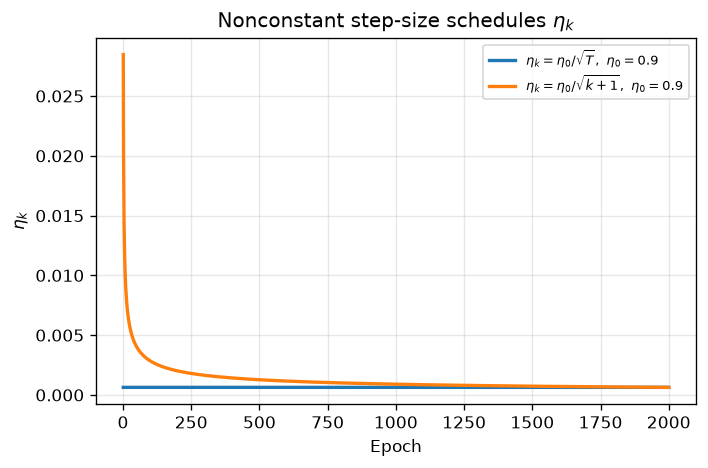

In [4]:
# ============================================================
# Plot single-run behavior
# ============================================================

def schedule_formula_label(result):
    schedule = result["schedule"]
    eta0 = schedule["eta0"]
    if schedule["kind"] == "constant":
        return rf"$\eta_k={eta0:g}$"
    if schedule["kind"] == "horizon_sqrt":
        return rf"$\eta_k=\eta_0/\sqrt{{T}},\ \eta_0={eta0:g}$"
    if schedule["kind"] == "diminishing_sqrt":
        return rf"$\eta_k=\eta_0/\sqrt{{k+1}},\ \eta_0={eta0:g}$"
    return schedule["kind"]


fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    hist = result["hist"]
    ax.semilogy(hist["epoch"], safe_gap(hist["objective_gap"]), linewidth=2, label=schedule_formula_label(result))
ax.set_title(r"Last iterate: $f(x_k)-f^\star$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$f(x_k)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    hist = result["hist"]
    ax.semilogy(hist["epoch"], safe_gap(hist["avg_objective_gap"]), linewidth=2, label=schedule_formula_label(result))
ax.set_title(r"Weighted average: $f(\bar{x}_k)-f^\star$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$f(\bar{x}_k)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    if result["schedule"]["kind"] == "constant":
        continue
    hist = result["hist"]
    positive_iter = hist["iter"] > 0
    ax.plot(hist["epoch"][positive_iter], hist["eta"][positive_iter], linewidth=2, label=schedule_formula_label(result))
ax.set_title(r"Nonconstant step-size schedules $\eta_k$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$\eta_k$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Constant step-size noise floor

The noisy-regime bound is stated for a weighted/ergodic average. This section therefore estimates the final weighted-average gap after a fixed run length for each constant step size.

For a constant step size, the first term decays but the second term remains proportional to $\eta$. This experiment estimates the final neighborhood for several constant step sizes.


In [5]:
# ============================================================
# Constant step-size floor experiment
# ============================================================

constant_etas = [0.05, 0.10, 0.20, 0.50, 0.90]
n_epochs_floor = 150
n_iters_floor = n_epochs_floor * A.shape[0]
n_repeats_floor = 8

floor_rows = []

for eta in constant_etas:
    print(f"Running constant eta = {eta}")
    avg_gaps, last_gaps, avg_distances = run_many_final_avg_gaps(
        A,
        b,
        n_iters=n_iters_floor,
        eta_schedule=make_schedule("constant", eta),
        f_star=f_star,
        x_star=x_star,
        n_repeats=n_repeats_floor,
        seed0=1000,
    )

    avg_summary = summarize_samples(avg_gaps)
    last_summary = summarize_samples(last_gaps)

    floor_rows.append({
        "eta": eta,
        "avg_gap_median": avg_summary["median"],
        "avg_gap_q25": avg_summary["q25"],
        "avg_gap_q75": avg_summary["q75"],
        "last_gap_median": last_summary["median"],
        "last_gap_q25": last_summary["q25"],
        "last_gap_q75": last_summary["q75"],
    })

print("\nConstant step-size floor summary")
print_rows(floor_rows, ["eta", "avg_gap_median", "last_gap_median"])


Running constant eta = 0.05
Running constant eta = 0.1
Running constant eta = 0.2
Running constant eta = 0.5
Running constant eta = 0.9

Constant step-size floor summary
         eta avg_gap_median last_gap_median
-------------------------------------------
  5.0000e-02     1.9846e-01      1.1849e-02
  1.0000e-01     6.7210e-02      2.2811e-02
  2.0000e-01     4.2560e-02      4.7161e-02
  5.0000e-01     7.0381e-02      1.4333e-01
  9.0000e-01     1.4639e-01      3.3872e-01


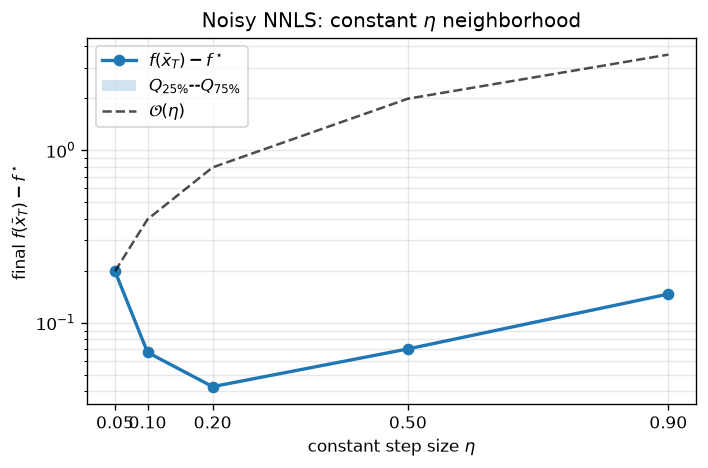

In [6]:
# ============================================================
# Plot constant step-size floor
# ============================================================

etas = np.array([row["eta"] for row in floor_rows])
med = np.array([row["avg_gap_median"] for row in floor_rows])
q25 = np.array([row["avg_gap_q25"] for row in floor_rows])
q75 = np.array([row["avg_gap_q75"] for row in floor_rows])

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(etas, safe_gap(med), marker="o", linewidth=2, label=r"$f(\bar{x}_T)-f^\star$")
ax.fill_between(etas, safe_gap(q25), safe_gap(q75), alpha=0.2, label=r"$Q_{25\%}$--$Q_{75\%}$")

ref = med[0] * (etas / etas[0])
ax.semilogy(etas, safe_gap(ref), linestyle="--", color="black", alpha=0.7, label=r"$\mathcal{O}(\eta)$")

ax.set_xlabel(r"constant step size $\eta$")
ax.set_xticks(etas)
ax.set_ylabel(r"final $f(\bar{x}_T)-f^\star$")
ax.set_title(r"Noisy NNLS: constant $\eta$ neighborhood")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Horizon-tuned rate check

For each horizon $T$, this experiment uses the constant-within-run step size

$$
\eta_k=\frac{\eta_0}{\sqrt{T}}.
$$

This cell checks how the weighted-average objective gap behaves as the run horizon $T$ changes under the horizon-tuned step size.


In [7]:
# ============================================================
# Horizon-tuned eta0/sqrt(T) experiment
# ============================================================

# horizon_epochs = [25, 50, 100, 200, 500, 1000, 2000]
horizon_epochs = [10, 25, 50, 100, 250, 500, 1000, 2000]
eta0_horizon = 0.9
n_repeats_rate = 8

rate_rows = []

for epochs in horizon_epochs:
    T = epochs * A.shape[0]
    print(f"Running horizon T = {T} row updates")
    avg_gaps, last_gaps, avg_distances = run_many_final_avg_gaps(
        A,
        b,
        n_iters=T,
        eta_schedule=make_schedule("horizon_sqrt", eta0_horizon),
        f_star=f_star,
        x_star=x_star,
        n_repeats=n_repeats_rate,
        seed0=2000,
    )

    avg_summary = summarize_samples(avg_gaps)
    last_summary = summarize_samples(last_gaps)

    rate_rows.append({
        "T": T,
        "epochs": epochs,
        "eta": eta0_horizon / np.sqrt(T),
        "avg_gap_median": avg_summary["median"],
        "avg_gap_q25": avg_summary["q25"],
        "avg_gap_q75": avg_summary["q75"],
        "last_gap_median": last_summary["median"],
        "last_gap_q25": last_summary["q25"],
        "last_gap_q75": last_summary["q75"],
    })

T_values = np.array([row["T"] for row in rate_rows], dtype=float)
rate_medians = safe_gap(np.array([row["avg_gap_median"] for row in rate_rows], dtype=float))
rate_slope, rate_intercept = np.polyfit(np.log(T_values), np.log(rate_medians), 1)

print("\nHorizon-tuned summary")
print_rows(rate_rows, ["T", "epochs", "eta", "avg_gap_median", "last_gap_median"])
print("\nlog-log slope for median weighted-average gap:", rate_slope)


Running horizon T = 10000 row updates
Running horizon T = 25000 row updates
Running horizon T = 50000 row updates
Running horizon T = 100000 row updates
Running horizon T = 250000 row updates
Running horizon T = 500000 row updates
Running horizon T = 1000000 row updates
Running horizon T = 2000000 row updates

Horizon-tuned summary
           T       epochs          eta avg_gap_median last_gap_median
---------------------------------------------------------------------
       10000           10   9.0000e-03     1.1977e+02      7.6532e+01
       25000           25   5.6921e-03     9.5196e+01      4.7595e+01
       50000           50   4.0249e-03     7.4989e+01      2.8825e+01
      100000          100   2.8460e-03     5.5143e+01      1.4825e+01
      250000          250   1.8000e-03     3.2556e+01      4.5336e+00
      500000          500   1.2728e-03     1.9894e+01      1.3600e+00
     1000000         1000   9.0000e-04     1.1274e+01      2.8330e-01
     2000000         2000   6.3640e-

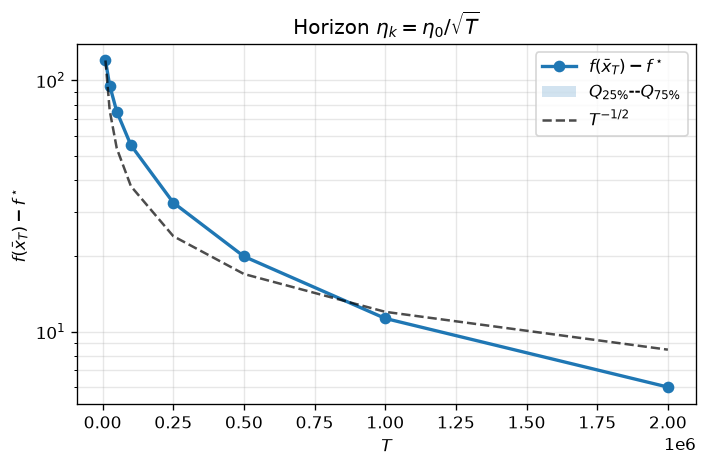

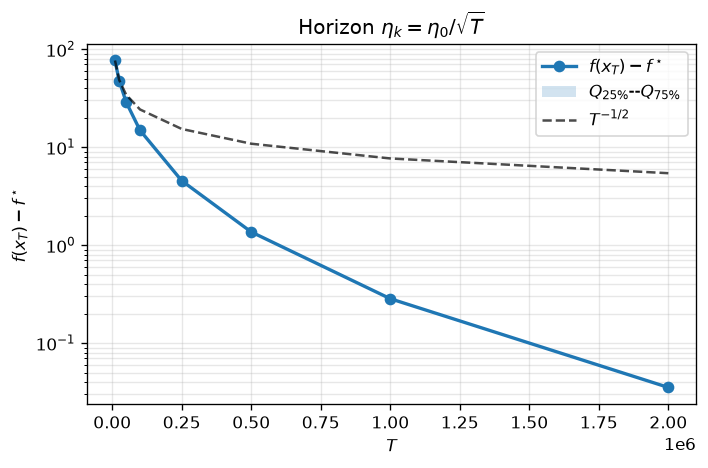

In [8]:
# ============================================================
# Plot horizon-tuned rate
# ============================================================

T_values = np.array([row["T"] for row in rate_rows], dtype=float)

# Theory-facing weighted-average metric
med = safe_gap(np.array([row["avg_gap_median"] for row in rate_rows], dtype=float))
q25 = safe_gap(np.array([row["avg_gap_q25"] for row in rate_rows], dtype=float))
q75 = safe_gap(np.array([row["avg_gap_q75"] for row in rate_rows], dtype=float))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(T_values, med, marker="o", linewidth=2, label=r"$f(\bar{x}_T)-f^\star$")
ax.fill_between(T_values, q25, q75, alpha=0.2, label=r"$Q_{25\%}$--$Q_{75\%}$")

ref = med[0] * (T_values / T_values[0]) ** (-0.5)
ax.semilogy(T_values, ref, linestyle="--", color="black", alpha=0.7, label=r"$T^{-1/2}$")

ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$f(\bar{x}_T)-f^\star$")
ax.set_title(rf"Horizon $\eta_k=\eta_0/\sqrt{{T}}$")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


# Practical last-iterate reference metric
last_med = safe_gap(np.array([row["last_gap_median"] for row in rate_rows], dtype=float))
last_q25 = safe_gap(np.array([row["last_gap_q25"] for row in rate_rows], dtype=float))
last_q75 = safe_gap(np.array([row["last_gap_q75"] for row in rate_rows], dtype=float))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(T_values, last_med, marker="o", linewidth=2, label=r"$f(x_T)-f^\star$")
ax.fill_between(T_values, last_q25, last_q75, alpha=0.2, label=r"$Q_{25\%}$--$Q_{75\%}$")

last_ref = last_med[0] * (T_values / T_values[0]) ** (-0.5)
ax.semilogy(T_values, last_ref, linestyle="--", color="black", alpha=0.7, label=r"$T^{-1/2}$")

ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$f(x_T)-f^\star$")
ax.set_title(rf"Horizon $\eta_k=\eta_0/\sqrt{{T}}$")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Paper-style figure export

This section saves compact PDF figures for the noisy NNLS experiment. Run Sections 2--5 first so that `single_results`, `floor_rows`, and `rate_rows` exist.


Saved: figures_nnls_noisy/fig_nnls_noisy_last_iterate_gap.pdf


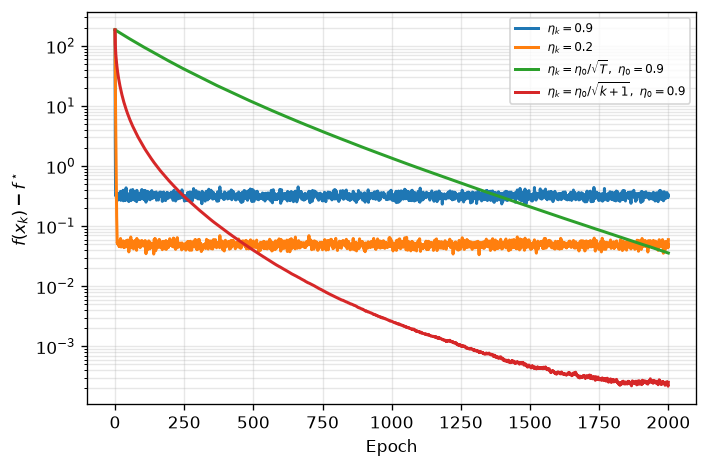

Saved: figures_nnls_noisy/fig_nnls_noisy_weighted_average_gap.pdf


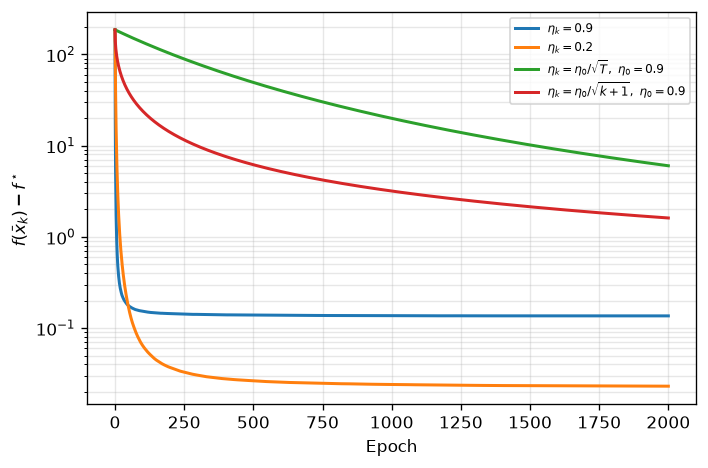

Saved: figures_nnls_noisy/fig_nnls_noisy_stepsize_schedule.pdf


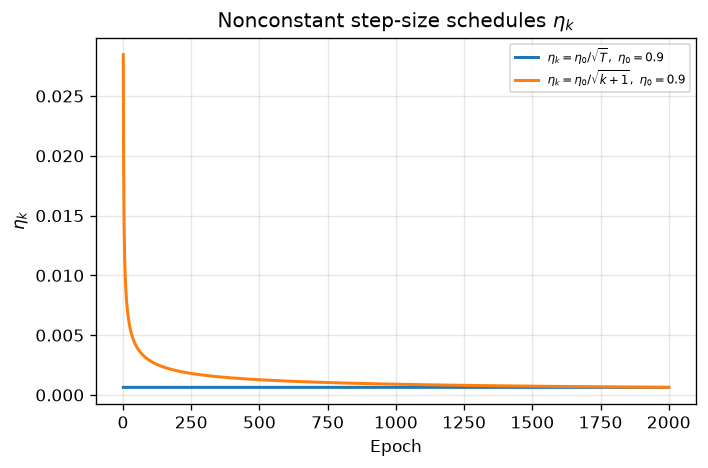

Saved: figures_nnls_noisy/fig_nnls_noisy_constant_eta_floor.pdf


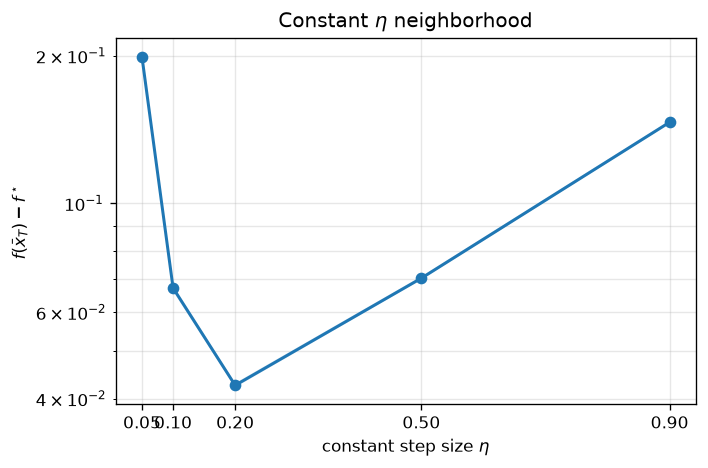

Saved: figures_nnls_noisy/fig_nnls_noisy_horizon_rate.pdf
Saved: figures_nnls_noisy/fig_nnls_noisy_avg_horizon_rate.pdf


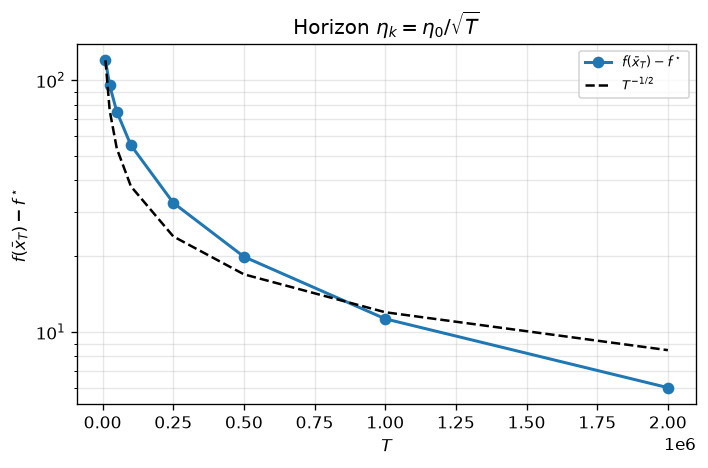

Saved: figures_nnls_noisy/fig_nnls_noisy_horizon_rate_last_iterate.pdf


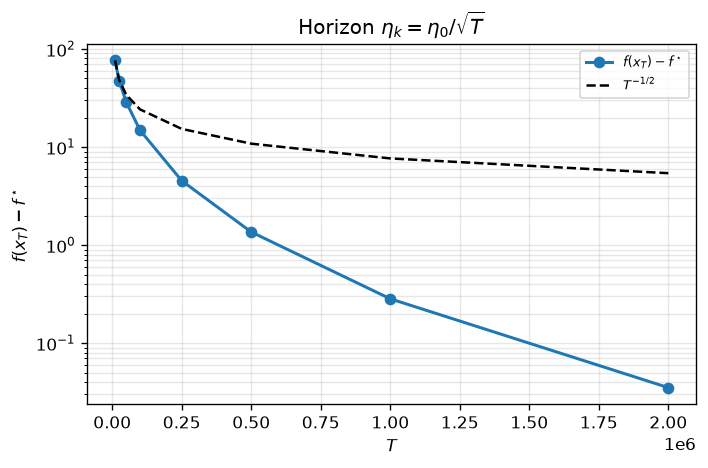

In [9]:
# ============================================================
# Save publication-style PDF figures
# ============================================================

FIG_DIR = Path("figures_nnls_noisy")
FIG_DIR.mkdir(exist_ok=True)


def schedule_formula_label(result):
    schedule = result["schedule"]
    eta0 = schedule["eta0"]
    if schedule["kind"] == "constant":
        return rf"$\eta_k={eta0:g}$"
    if schedule["kind"] == "horizon_sqrt":
        return rf"$\eta_k=\eta_0/\sqrt{{T}},\ \eta_0={eta0:g}$"
    if schedule["kind"] == "diminishing_sqrt":
        return rf"$\eta_k=\eta_0/\sqrt{{k+1}},\ \eta_0={eta0:g}$"
    return schedule["kind"]


def save_pdf(fig, filename, dpi=600):
    path = FIG_DIR / filename
    fig.savefig(path, format="pdf", dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    print(f"Saved: {path}")


# Figure A0: representative last-iterate schedule comparison, for reference
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    hist = result["hist"]
    ax.semilogy(hist["epoch"], safe_gap(hist["objective_gap"]), linewidth=1.8, label=schedule_formula_label(result))
# ax.set_title(r"Last iterate: $f(x_k)-f^\star$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$f(x_k)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_last_iterate_gap.pdf")
plt.show()


# Figure A1: representative weighted-average schedule comparison
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    hist = result["hist"]
    ax.semilogy(hist["epoch"], safe_gap(hist["avg_objective_gap"]), linewidth=1.8, label=schedule_formula_label(result))
# ax.set_title(r"Weighted average: $f(\bar{x}_k)-f^\star$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$f(\bar{x}_k)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_weighted_average_gap.pdf")
plt.show()


# Figure A2: step-size schedule comparison
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
for name, result in single_results.items():
    if result["schedule"]["kind"] == "constant":
        continue
    hist = result["hist"]
    positive_iter = hist["iter"] > 0
    ax.plot(hist["epoch"][positive_iter], hist["eta"][positive_iter], linewidth=1.8, label=schedule_formula_label(result))
ax.set_title(r"Nonconstant step-size schedules $\eta_k$")
ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$\eta_k$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_stepsize_schedule.pdf")
plt.show()


# Figure B1: constant eta floor, weighted-average metric
etas = np.array([row["eta"] for row in floor_rows])
floor_med = safe_gap(np.array([row["avg_gap_median"] for row in floor_rows]))
floor_q25 = safe_gap(np.array([row["avg_gap_q25"] for row in floor_rows]))
floor_q75 = safe_gap(np.array([row["avg_gap_q75"] for row in floor_rows]))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(etas, floor_med, marker="o", linewidth=1.8)
ax.fill_between(etas, floor_q25, floor_q75, alpha=0.2)
ax.set_title(r"Constant $\eta$ neighborhood")
ax.set_xlabel(r"constant step size $\eta$")
ax.set_xticks(etas)
ax.set_ylabel(r"$f(\bar{x}_T)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_constant_eta_floor.pdf")
plt.show()


# Figure B2: horizon-tuned rate, weighted-average metric
T_values = np.array([row["T"] for row in rate_rows], dtype=float)
rate_med = safe_gap(np.array([row["avg_gap_median"] for row in rate_rows], dtype=float))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(T_values, rate_med, marker="o", linewidth=1.8, label=r"$f(\bar{x}_T)-f^\star$")
ax.semilogy(T_values, rate_med[0] * (T_values / T_values[0]) ** (-0.5), linestyle="--", color="black", label=r"$T^{-1/2}$")
# ax.set_title(rf"Horizon $\eta_k=\eta_0/\sqrt{{T}}$, slope {rate_slope:.2f}")
ax.set_title(rf"Horizon $\eta_k=\eta_0/\sqrt{{T}}$")
ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$f(\bar{x}_T)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_horizon_rate.pdf")
# Alias used by the current paper source. The original filename above is retained.
save_pdf(fig, "fig_nnls_noisy_avg_horizon_rate.pdf")
plt.show()

# Figure B3: horizon-tuned rate, last-iterate metric for reference
T_values = np.array([row["T"] for row in rate_rows], dtype=float)
rate_last_med = safe_gap(np.array([row["last_gap_median"] for row in rate_rows], dtype=float))

fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
ax.semilogy(T_values, rate_last_med, marker="o", linewidth=1.8, label=r"$f(x_T)-f^\star$")
ax.semilogy(T_values, rate_last_med[0] * (T_values / T_values[0]) ** (-0.5), linestyle="--", color="black", label=r"$T^{-1/2}$")
ax.set_title(rf"Horizon $\eta_k=\eta_0/\sqrt{{T}}$")
ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$f(x_T)-f^\star$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
save_pdf(fig, "fig_nnls_noisy_horizon_rate_last_iterate.pdf")
plt.show()

